# EnergiFlow — Analyse exploratoire (Bloc 2)
Analyse pas à pas des données réelles collectées (couche `silver` dans PostgreSQL).

**Avant de lancer** : sélectionne le bon interpréteur Python en haut à droite de VS Code (celui de ton environnement virtuel `venv`, pas le Python système).

## 0. Connexion à PostgreSQL
⚠️ On est **hors Docker** ici (notebook local) : on utilise `localhost` et le port **5433** (celui exposé dans `docker-compose.yml`), pas `postgres`/`5432` qui ne fonctionne qu'à l'intérieur du réseau Docker.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

%matplotlib inline


In [3]:
POSTGRES_HOST = "localhost"
POSTGRES_PORT = "5433"
POSTGRES_DB = "energiflow"
POSTGRES_USER = "energiflow"
POSTGRES_PASSWORD = "energiflow"

engine = create_engine(
    f"postgresql+psycopg2://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"
)
print("Connexion prête.")


Connexion prête.


## 1. Extraction des données
On récupère les vues déjà nettoyées de la couche Silver.

In [4]:
df_national = pd.read_sql("SELECT * FROM silver.conso_meteo_prix ORDER BY date_heure", engine)
df_regional = pd.read_sql("SELECT * FROM silver.consommation_regionale ORDER BY date_heure", engine)

print(f"{len(df_national)} lignes (national), {len(df_regional)} lignes (régional)")
df_national.head()


47047 lignes (national), 279312 lignes (régional)


,date_heure,consommation_mw,temperature_moyenne_nationale,vent_moyen_national,prix_eur_mwh
0,2024-12-31 23:00:00+00:00,64354.0,NaN,NaN,NaN
1,2024-12-31 23:15:00+00:00,64521.0,NaN,NaN,NaN
2,2024-12-31 23:30:00+00:00,63715.0,NaN,NaN,NaN
3,2024-12-31 23:45:00+00:00,62502.0,NaN,NaN,NaN
4,2025-01-01 00:00:00+00:00,61490.0,3.06,11.98,NaN


## 2. Statistiques descriptives
Vue d'ensemble : moyenne, écart-type, min/max, quartiles.

In [5]:
desc = df_national["consommation_mw"].describe()
desc


count    47047.000000
mean     49679.675558
std      10393.275458
min      29044.000000
25%      41939.500000
50%      47881.000000
75%      56351.000000
max      89273.000000
Name: consommation_mw, dtype: float64

## 3. Évolution temporelle de la consommation nationale

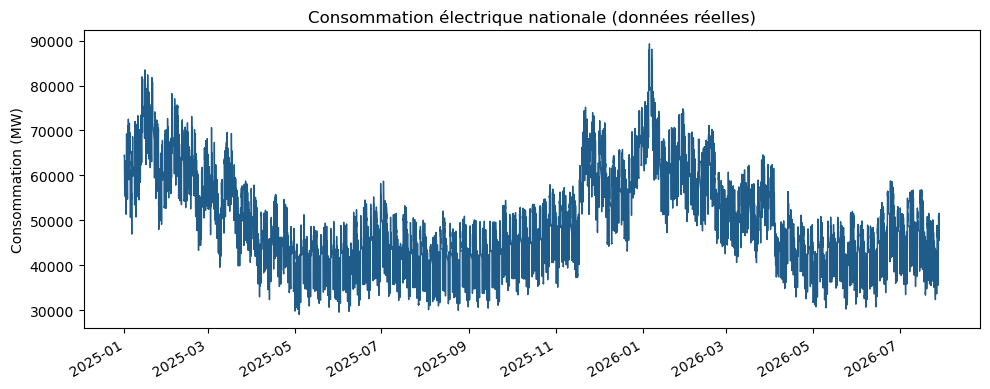

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_national["date_heure"], df_national["consommation_mw"], color="#1f5c8a", linewidth=1)
ax.set_title("Consommation électrique nationale (données réelles)")
ax.set_ylabel("Consommation (MW)")
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()


## 4. Consommation moyenne par région

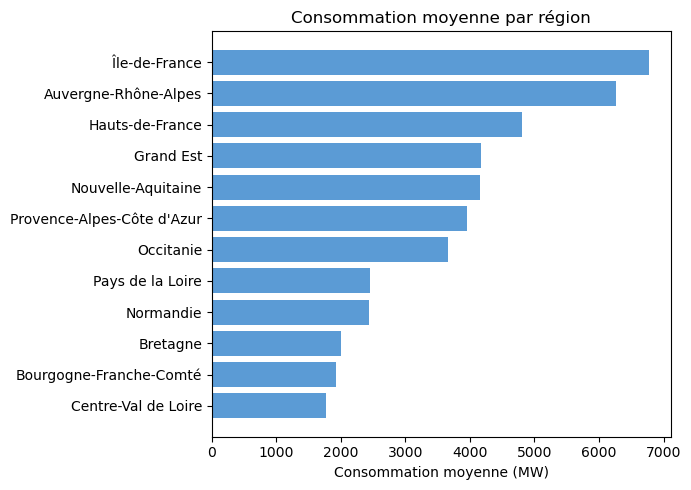

region
Île-de-France                 6773.095238
Auvergne-Rhône-Alpes          6269.166667
Hauts-de-France               4808.598214
Grand Est                     4175.116071
Nouvelle-Aquitaine            4154.235119
Provence-Alpes-Côte d'Azur    3961.366071
Occitanie                     3653.324405
Pays de la Loire              2448.047619
Normandie                     2429.711310
Bretagne                      2005.494048
Bourgogne-Franche-Comté       1923.345238
Centre-Val de Loire           1773.940476
Name: consommation_mw, dtype: float64

In [6]:
reg_moy = df_regional.groupby("region")["consommation_mw"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(reg_moy.index, reg_moy.values, color="#5b9bd5")
ax.set_title("Consommation moyenne par région")
ax.set_xlabel("Consommation moyenne (MW)")
fig.tight_layout()
plt.show()

reg_moy.sort_values(ascending=False)


## 5. Corrélation température / consommation
Test de Pearson : la relation est-elle statistiquement significative ?

In [6]:
df_temp = df_national.dropna(subset=["temperature_moyenne_nationale", "consommation_mw"])
r_temp, p_temp = stats.pearsonr(df_temp["temperature_moyenne_nationale"], df_temp["consommation_mw"])
print(f"r = {r_temp:.3f}, p = {p_temp:.4g}, n = {len(df_temp)}")


r = -0.556, p = 0, n = 47043


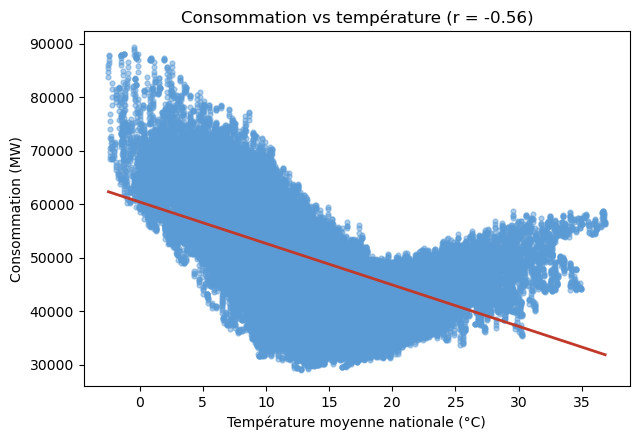

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(df_temp["temperature_moyenne_nationale"], df_temp["consommation_mw"],
           s=12, alpha=0.5, color="#5b9bd5")
z = np.polyfit(df_temp["temperature_moyenne_nationale"], df_temp["consommation_mw"], 1)
xs = np.linspace(df_temp["temperature_moyenne_nationale"].min(),
                  df_temp["temperature_moyenne_nationale"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color="#c0392b", linewidth=2)
ax.set_title(f"Consommation vs température (r = {r_temp:.2f})")
ax.set_xlabel("Température moyenne nationale (°C)")
ax.set_ylabel("Consommation (MW)")
fig.tight_layout()
plt.show()


## 6. Matrice de corrélation
Toutes les variables numériques croisées entre elles.

In [9]:
corr_cols = ["consommation_mw", "temperature_moyenne_nationale", "vent_moyen_national", "prix_eur_mwh"]
corr_matrix = df_national[corr_cols].corr()
corr_matrix.round(3)


,consommation_mw,temperature_moyenne_nationale,vent_moyen_national,prix_eur_mwh
consommation_mw,1.000,-0.556,0.176,-0.380
temperature_moyenne_nationale,-0.556,1.000,-0.042,-0.158
vent_moyen_national,0.176,-0.042,1.000,-0.008
prix_eur_mwh,-0.380,-0.158,-0.008,1.000


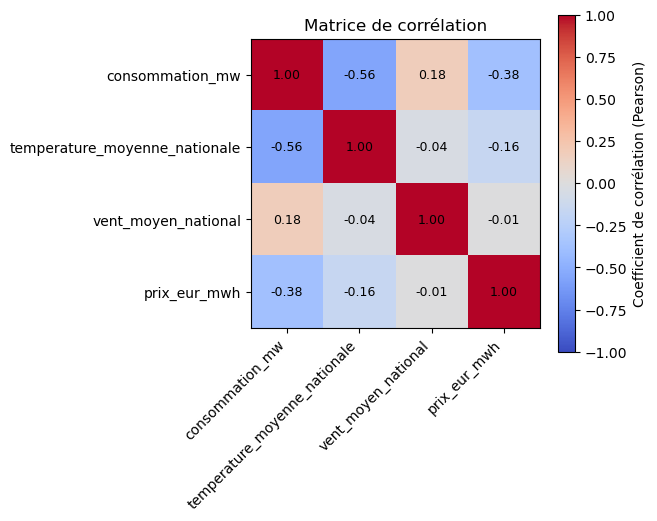

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        text = f"{val:.2f}" if pd.notna(val) else "n/a"
        ax.text(j, i, text, ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im, ax=ax, label="Coefficient de corrélation (Pearson)")
ax.set_title("Matrice de corrélation")
fig.tight_layout()
plt.show()


## 7. Distribution horaire (boxplot)
Pas encore de saisonnalité disponible (données limitées à quelques jours), mais le cycle journalier, lui, est déjà observable.

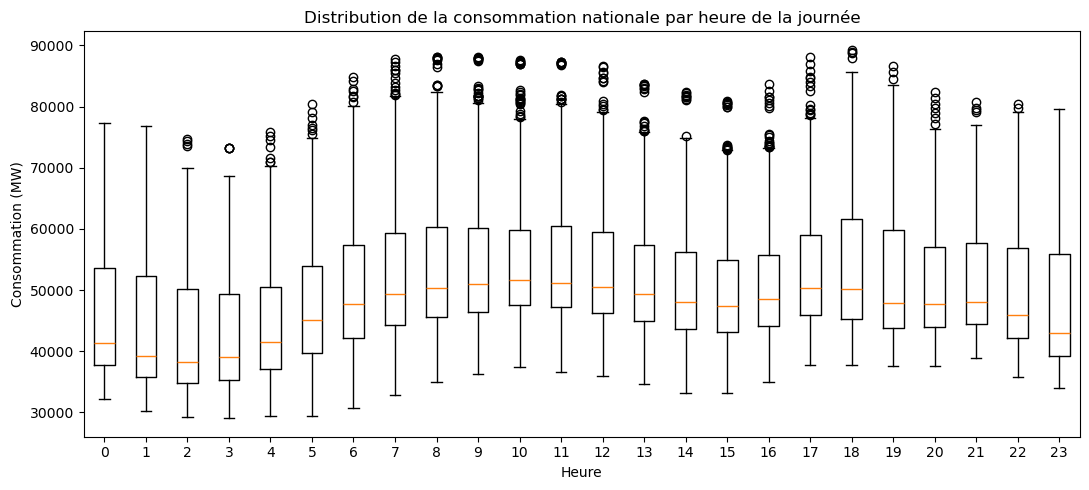

In [11]:
df_national["heure"] = pd.to_datetime(df_national["date_heure"]).dt.hour
data_by_hour = [df_national.loc[df_national["heure"] == h, "consommation_mw"].dropna().values for h in range(24)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data_by_hour, tick_labels=list(range(24)))
ax.set_title("Distribution de la consommation nationale par heure de la journée")
ax.set_xlabel("Heure"); ax.set_ylabel("Consommation (MW)")
fig.tight_layout()
plt.show()


## 8. Détection de dérives (valeurs aberrantes)
Z-score au-delà de ±3 = valeur statistiquement anormale.

In [12]:
moyenne = df_national["consommation_mw"].mean()
ecart_type = df_national["consommation_mw"].std()
df_national["z_score"] = (df_national["consommation_mw"] - moyenne) / ecart_type

outliers = df_national.loc[df_national["z_score"].abs() > 3, ["date_heure", "consommation_mw", "z_score"]]
print(f"{len(outliers)} valeur(s) aberrante(s) sur {len(df_national)} lignes")
outliers


155 valeur(s) aberrante(s) sur 47047 lignes


,date_heure,consommation_mw,z_score
1090,2025-01-13 07:30:00+00:00,81104.0,3.023525
1091,2025-01-13 07:45:00+00:00,81523.0,3.063839
1092,2025-01-13 08:00:00+00:00,81668.0,3.077790
1093,2025-01-13 08:15:00+00:00,81752.0,3.085873
1094,2025-01-13 08:30:00+00:00,81948.0,3.104731
...,...,...,...
30264,2026-01-07 18:30:00+00:00,85178.0,3.415509
30265,2026-01-07 18:45:00+00:00,84280.0,3.329107
30266,2026-01-07 19:00:00+00:00,83237.0,3.228753
30267,2026-01-07 19:15:00+00:00,82424.0,3.150530


## 9. Normalisation et standardisation
- **Standardisation (z-score)** : moyenne 0, écart-type 1 — utile pour comparer des variables d'échelles différentes.
- **Normalisation (min-max)** : ramène entre 0 et 1 — utile pour certains algorithmes de ML.

In [12]:
df_national["consommation_standardisee"] = (df_national["consommation_mw"] - moyenne) / ecart_type
df_national["consommation_normalisee_minmax"] = (
    (df_national["consommation_mw"] - df_national["consommation_mw"].min())
    / (df_national["consommation_mw"].max() - df_national["consommation_mw"].min())
)
df_national[["date_heure", "consommation_mw", "consommation_standardisee", "consommation_normalisee_minmax"]].head()


NameError: name 'moyenne' is not defined